**Proje Konusu: YSA’ların sınırları**

25*25’lik binary bir matris girişine karşılık aşağıdaki çıktıları üreten 5 YSA eğitiniz.

- A) Matriste 5 nokta (rasgele konumlarda) bulunmaktadır. Model bu noktalardan birbirine en yakın olan ikisi arasındaki Manhattan mesafesini çıktı olarak verecektir. 
- B) A’nin aynısı sadece en yakın yerine en uzak olan ikisi… 
- C) Matriste değişken sayıda (her girişte farklı sayıda olabilir) N adet (1 10 arası) nokta (rasgele konumlarda) bulunmaktadır. Model nokta sayısını çıktı olarak verecektir. 
- D) C’nin aynısı ama çıkış, nokta sayısının tek mi çift mi olduğu 
- E) C’nin aynısı ama çıkış, nokta sayısı tek ise sol üst köşeye en yakın olan noktanın sol üst köşeye Manhattan mesafesi, çift ise sağ alt köşeye en yakın olan noktanın sağ alt köşeye Manhattan mesafesi

YSA modeli olarak RNN, MLP, CNN, Transformer vb. istediğinizi kullanabilirsiniz.<br> 
Her problemde farklı birini de aynılarını da kullanabilirsiniz.

- 5 problemin her biri için: En az 800 örneğe sahip eğitim, 200 örneğe sahip test kümesi oluşturunuz.
- Her eğitim ve test kümesinde çıkışların dağılımı eşit olmalıdır. Örneğin A’da aradaki mesafeler 1-50 aralığında değişiyorsa her aralıktan eşit sayıda örnek olmalıdır. Kümeler buna göre oluşturulmalıdır.
- YSA ların hiperparametre optimizasyonunu nasıl yaptığınızı raporlayınız.
- Eğitim kümesinin çeyrek, yarım ve tam halleri için eğitim yapıp test kümesi üzerindeki performansını raporlayınız.
- Yanlış ve doğru yapılan test örneklerini kendi gözünüzle inceleyip, modellerin neyi öğrenebildiğini / öğrenemediğini yorumlayınız.
- Bulgularınızı tablolar ve grafiklerle sunun, yorumlayın.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from util import load_dataset, plot_mat

GRID_SIZE = 25

In [21]:
x_train, y_train, x_test, y_test = load_dataset('A')

[+] Problem A veri seti başarıyla yüklendi.
    Train -> X: (840, 25, 25), y: (840,)
    Test  -> X: (210, 25, 25), y: (210,)


In [36]:
class ProblemACNN(nn.Module):
    def __init__(self):
        super().__init__()

        # g_theta Ağı: 4 koordinatı (y1, x1, y2, x2) alıp 16 boyutlu bir ilişki vektörü çıkarır
        self.g_theta = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # f_phi Ağı: Agrege edilmiş (özetlenmiş) 16 boyutlu vektörü alıp skaler mesafeyi tahmin eder
        self.f_phi = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.ReLU() # Mesafe negatif olamayacağı için sonda ReLU
        )

    def forward(self, x):
        # x'in beklenen boyutu: (BatchSize, 25, 25)
        batch_size = x.shape[0]
        
        # 1. EXTRACTION (Koordinatları çıkarma)
        # x == 1 olan konumların indekslerini alıyoruz. Sonuç: (BatchSize * 5, 3) -> [batch_idx, y, x]
        raw_coords = torch.nonzero(x == 1)
        
        # Bize sadece (y, x) lazım. İndeksler tam sayı (int) döner, ağ için float'a çeviriyoruz.
        # Her batch'te tam 5 nokta olduğu için doğrudan reshape yapabiliriz.
        objects = raw_coords[:, 1:].view(batch_size, 5, 2).float() 
        
        # 2. PAIRING (İkili eşleşmeleri oluşturma)
        # Boyutları genişleterek 5x5'lik eşleşme ızgarasını kuruyoruz.
        obj_i = objects.unsqueeze(2).expand(batch_size, 5, 5, 2) # (B, 5, 1, 2) -> (B, 5, 5, 2)
        obj_j = objects.unsqueeze(1).expand(batch_size, 5, 5, 2) # (B, 1, 5, 2) -> (B, 5, 5, 2)
        
        # Koordinatları yan yana yapıştırıyoruz. Sonuç: (BatchSize, 5, 5, 4)
        pairs = torch.cat([obj_i, obj_j], dim=-1)
        
        # 3. g_theta AĞINDAN GEÇİRME
        # MLP'ye sokmak için matrisi 2 boyutlu hale getiriyoruz: (BatchSize * 25, 4)
        g_in = pairs.view(batch_size * 25, 4)
        g_out = self.g_theta(g_in) # Çıktı boyutu: (BatchSize * 25, 16)
        
        # 4. AGGREGATION (Toplama/Havuzlama)
        # Hangi 25 eşleşmenin hangi batch'e ait olduğunu ayırıyoruz.
        g_out = g_out.view(batch_size, 25, 16)
        
        # En kısa mesafeyi aradığımız için, 25 eşleşme arasından minimum olanı alıyoruz.
        # torch.min hem değerleri hem indeksleri döner, bize sadece değerler (0. indeks) lazım.
        agg_out, _ = torch.min(g_out, dim=1) # Çıktı boyutu: (BatchSize, 16)
        
        # 5. f_phi AĞINDAN GEÇİRME VE NİHAİ KARAR
        out = self.f_phi(agg_out) # Çıktı boyutu: (BatchSize, 1)
        
        return out

In [ ]:
x_train_tensor = torch.tensor(x_train).float()
y_train_tensor = torch.tensor(y_train).float()
x_test_tensor = torch.tensor(x_test).float()
y_test_tensor = torch.tensor(y_test).float()

# 2. Artık Tensör oldukları için TensorDataset sorunsuz çalışacaktır
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Model, Loss ve Optimizatör
model = ProblemACNN()

criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Eğitim Döngüsü (Training Loop)
epochs = 500

In [63]:
for epoch in range(epochs):
    # --- EĞİTİM (TRAIN) FAZI ---
    model.train() # Modeli eğitim moduna al
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad() # Önceki adımdan kalan gradyanları temizle
        
        # 1. İleri Yayılım (Forward Pass)
        predictions = model(batch_x) 
        
        # 2. Hata Hesaplama
        # predictions (Batch, 1) boyutundadır. batch_y'nin de (Batch, 1) olduğundan emin oluyoruz.
        loss = criterion(predictions, batch_y.view(-1, 1).float())
        
        # 3. Geri Yayılım (Backward Pass)
        loss.backward()
        
        # 4. Ağırlıkları Güncelleme
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- DOĞRULAMA (EVALUATION) FAZI ---
    model.eval() # Modeli test moduna al (dropout vs varsa kapatır)
    test_loss = 0.0
    
    with torch.no_grad(): # Test sırasında türev/gradyan hesaplamaya gerek yok, bellekten tasarruf
        for batch_x, batch_y in test_loader:
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y.view(-1, 1).float())
            test_loss += loss.item()
            
    avg_test_loss = test_loss / len(test_loader)
    
    # İlerlemeyi Ekrana Yazdırma (Her 5 Epoch'ta bir)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

# Eğitilmiş modeli kaydetmek istersen:
# torch.save(model.state_dict(), 'relational_net.pth')

Epoch [100/1000] | Train Loss: 1.8741 | Test Loss: 2.4701
Epoch [200/1000] | Train Loss: 0.6751 | Test Loss: 0.2800
Epoch [300/1000] | Train Loss: 1.1880 | Test Loss: 0.3914
Epoch [400/1000] | Train Loss: 0.0219 | Test Loss: 0.0781
Epoch [500/1000] | Train Loss: 0.4782 | Test Loss: 0.1636
Epoch [600/1000] | Train Loss: 2.5136 | Test Loss: 3.4946
Epoch [700/1000] | Train Loss: 0.0138 | Test Loss: 0.0554
Epoch [800/1000] | Train Loss: 0.0406 | Test Loss: 0.0696
Epoch [900/1000] | Train Loss: 0.4533 | Test Loss: 0.1459
Epoch [1000/1000] | Train Loss: 0.7550 | Test Loss: 0.1941


In [74]:
def predict(model, x_data):
    model.eval()
    is_single = (len(x_data.shape) == 2)
    if is_single:
        x_data = np.expand_dims(x_data, axis=0)
    x_tensor = torch.tensor(x_data).float()
    with torch.no_grad():
        sonuc = model(x_tensor)
    sonuc_array = np.round(sonuc.numpy()).astype(int)
    if is_single:
        return int(sonuc_array[0, 0])
    else:
        return sonuc_array.flatten()

7


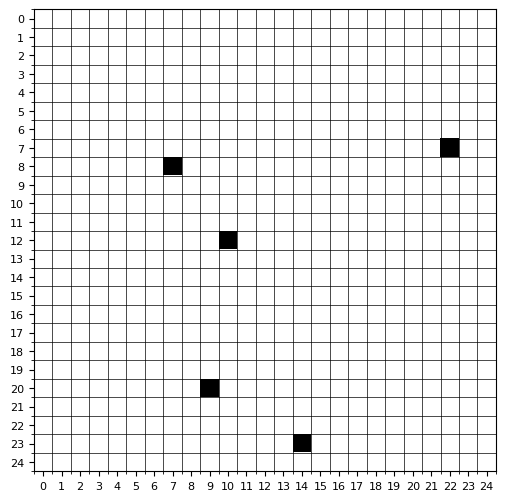

5

In [108]:
idx = 210
print(y_train[idx]);plot_mat(x_train[idx])
predict(model, x_train[idx])